In [1]:
import pandas as pd
import plotnine as p9

In [2]:
import numpy as np
import scanpy as sc

In [3]:
import anndata

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mplpatches

In [5]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=200)

/gstore/home/wub31/.conda/envs/py38_Scanpy_expanded/lib/python3.8/site-packages/numba/core/cpu.py:97: UserWarning: Numba extension module 'sparse._numba_extension' failed to load due to 'ModuleNotFoundError(No module named 'numba.targets')'.
/gstore/home/wub31/.conda/envs/py38_Scanpy_expanded/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
2023-03-15 14:20:57.173056: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-03-15 14:20:57.347271: W tensorflow/tsl/platform/default/dso_loader.cc:66] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared ob

scanpy==1.9.1 anndata==0.7.8 umap==0.5.3 numpy==1.23.5 scipy==1.9.3 pandas==1.5.2 scikit-learn==1.1.3 statsmodels==0.13.5 python-igraph==0.10.2 pynndescent==0.5.8


In [12]:
df_K562=pd.read_csv(SHAREseq_directoryname+'/GSM4156606_K562.Raw.rna.hg19.counts.txt.gz',sep='\t',header=0)

In [13]:
df_K562

,gene,"R1.65,R2.01,R3.04,P1.39","R1.65,R2.01,R3.28,P1.39","R1.65,R2.01,R3.47,P1.41","R1.65,R2.01,R3.93,P1.40","R1.65,R2.02,R3.13,P1.44","R1.65,R2.02,R3.53,P1.39","R1.65,R2.02,R3.55,P1.41","R1.65,R2.02,R3.60,P1.42","R1.65,R2.02,R3.84,P1.40",...,"R1.96,R2.92,R3.57,P1.42","R1.96,R2.93,R3.08,P1.45","R1.96,R2.93,R3.16,P1.39","R1.96,R2.94,R3.12,P1.43","R1.96,R2.94,R3.12,P1.45","R1.96,R2.94,R3.61,P1.39","R1.96,R2.94,R3.89,P1.45","R1.96,R2.95,R3.90,P1.42","R1.96,R2.96,R3.40,P1.45","R1.96,R2.96,R3.51,P1.41"
0,5S_rRNA,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7SK,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,A1BG,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,A1CF,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,A2M,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23238,hsa-mir-335,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
23239,hsa-mir-490,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
23240,hsa-mir-7515,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
23241,hsa-mir-8072,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [38]:
df_K562.columns

Index(['gene', 'R1.65,R2.01,R3.04,P1.39', 'R1.65,R2.01,R3.28,P1.39',
       'R1.65,R2.01,R3.47,P1.41', 'R1.65,R2.01,R3.93,P1.40',
       'R1.65,R2.02,R3.13,P1.44', 'R1.65,R2.02,R3.53,P1.39',
       'R1.65,R2.02,R3.55,P1.41', 'R1.65,R2.02,R3.60,P1.42',
       'R1.65,R2.02,R3.84,P1.40',
       ...
       'R1.96,R2.92,R3.57,P1.42', 'R1.96,R2.93,R3.08,P1.45',
       'R1.96,R2.93,R3.16,P1.39', 'R1.96,R2.94,R3.12,P1.43',
       'R1.96,R2.94,R3.12,P1.45', 'R1.96,R2.94,R3.61,P1.39',
       'R1.96,R2.94,R3.89,P1.45', 'R1.96,R2.95,R3.90,P1.42',
       'R1.96,R2.96,R3.40,P1.45', 'R1.96,R2.96,R3.51,P1.41'],
      dtype='object', length=8516)

In [41]:
adata = anndata.AnnData(X=np.transpose(df_K562.iloc[0:,1:].to_numpy()),obs=df_K562.columns[1:].to_frame(),var=df_K562['gene'].to_frame())              

In [42]:
adata

AnnData object with n_obs × n_vars = 8515 × 23243
    obs: 0
    var: 'gene'

In [43]:
adata.var

,gene
0,5S_rRNA
1,7SK
2,A1BG
3,A1CF
4,A2M
...,...
23238,hsa-mir-335
23239,hsa-mir-490
23240,hsa-mir-7515
23241,hsa-mir-8072


In [44]:
adata.obs

,0
"R1.65,R2.01,R3.04,P1.39","R1.65,R2.01,R3.04,P1.39"
"R1.65,R2.01,R3.28,P1.39","R1.65,R2.01,R3.28,P1.39"
"R1.65,R2.01,R3.47,P1.41","R1.65,R2.01,R3.47,P1.41"
"R1.65,R2.01,R3.93,P1.40","R1.65,R2.01,R3.93,P1.40"
"R1.65,R2.02,R3.13,P1.44","R1.65,R2.02,R3.13,P1.44"
...,...
"R1.96,R2.94,R3.61,P1.39","R1.96,R2.94,R3.61,P1.39"
"R1.96,R2.94,R3.89,P1.45","R1.96,R2.94,R3.89,P1.45"
"R1.96,R2.95,R3.90,P1.42","R1.96,R2.95,R3.90,P1.42"
"R1.96,R2.96,R3.40,P1.45","R1.96,R2.96,R3.40,P1.45"


In [45]:
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True) 

In [48]:
adata.obs['cell_type']="K562"

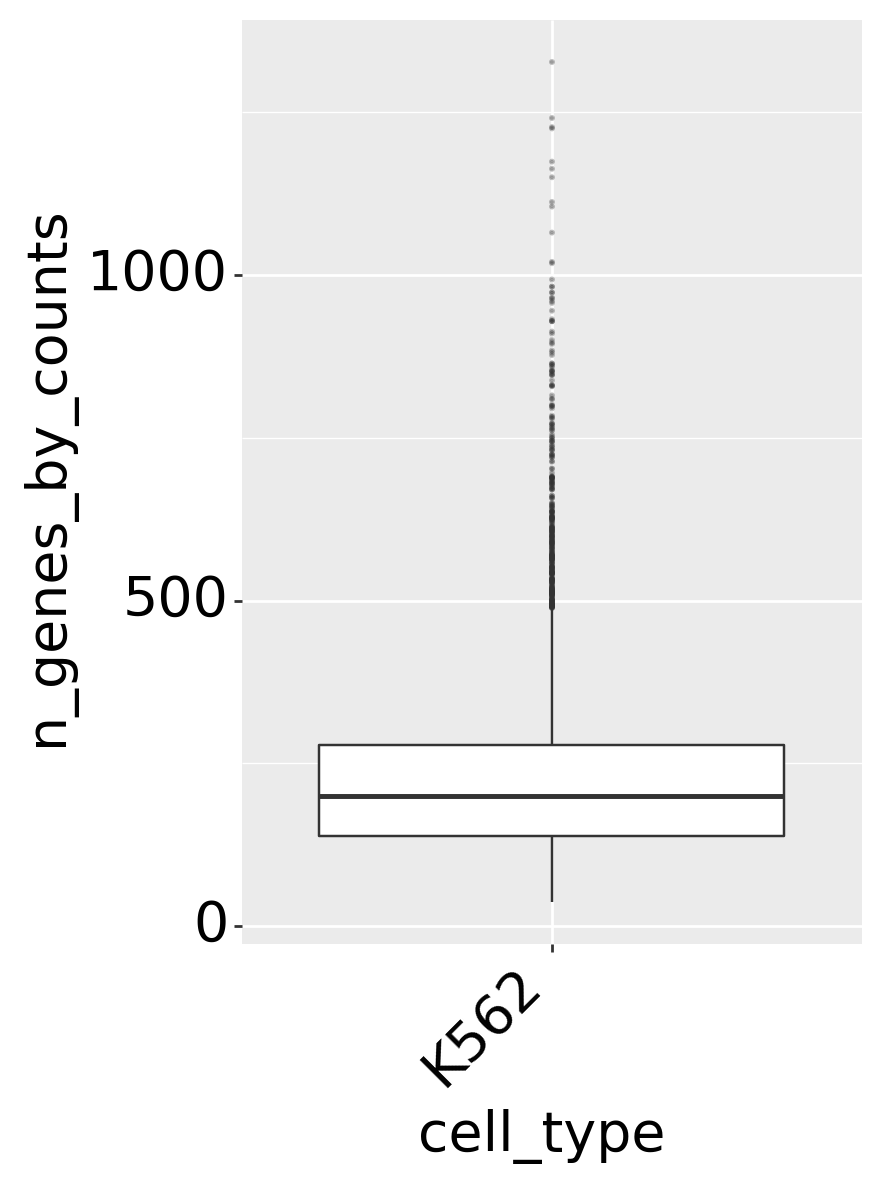

<ggplot: (2932438180732)>

In [49]:
plot=p9.ggplot(data=adata.obs,
               mapping=p9.aes(x='cell_type',y='n_genes_by_counts')
              )
plot+ p9.geom_boxplot(outlier_alpha=0.3,outlier_size=0.2) \
+ p9.theme(figure_size=(4, 6)) \
+ p9.theme(axis_text_x=p9.element_text(size=20, colour="black")) \
+ p9.theme(axis_text_x=p9.element_text(angle = 45, hjust = 1)) \
+ p9.theme(axis_text_y=p9.element_text(size=20, colour="black")) \
+ p9.theme(text=p9.element_text(size=20))